# 0152GBO — poultry incubation

RAMP calibration notebook. To study another client, edit the two
lines of the next cell and run everything again.

In [1]:
CLIENT = "0152GBO"
PUE_TYPE = "poultry_incubation"

# Study period to calibrate on (the meter file may hold more days than the
# appliance's service period; set both to None to use the whole file).
PERIOD_START = "2024-12-01"
PERIOD_END = "2025-12-15"

# Appliance rated power in W, used as a physical ceiling in the calibration
# (set to None to disable the cap).
RATED_POWER_W = 150

In [2]:
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

REPO = Path.cwd().resolve().parents[1]      # notebooks/<type>/ -> repository root
sys.path.append(str(REPO / "src"))
import run

RESULTS = REPO / "resultats" / PUE_TYPE / CLIENT
FIGURES = RESULTS / "figures"


def show(*patterns):
    """Display every figure matching the given file patterns, in order."""
    for pattern in patterns:
        for path in sorted(FIGURES.glob(pattern)):
            display(Image(filename=str(path), width=900))

## Run the full chain

The next cell runs the five steps (preprocessing, clustering,
calibration, figures, summary) on this client. Progress appears
below as it happens; the whole chain takes about 10 to 15 minutes.

In [3]:
run.run(PUE_TYPE, CLIENT, period_start=PERIOD_START,
        period_end=PERIOD_END, rated_power_W=RATED_POWER_W)

Running the poultry_incubation chain for 0152GBO ...


                         |          | 0/5 steps [00:00]

  Preprocessing          |          | 0/5 steps [00:00]

  Preprocessing          |██        | 1/5 steps [00:05]

  Clustering             |██        | 1/5 steps [00:05]

...

  Calibration figures    |████████  | 4/5 steps [03:41]

  Summary                |████████  | 4/5 steps [03:41]

  Summary                |██████████| 5/5 steps [03:43]

  Summary                |██████████| 5/5 steps [03:43]


Done -- 5 steps completed.


## Client identity card

In [4]:
clean = pd.read_csv(RESULTS / "timeseries_clean.csv", index_col=0,
                    parse_dates=True)
daily = pd.read_csv(RESULTS / "daily_matrix_W.csv", index_col=0,
                    parse_dates=True)
kept = pd.read_csv(RESULTS / "clustered_features.csv", index_col=0)
card = pd.Series({
    "Client": CLIENT,
    "PUE type": PUE_TYPE.replace("_", " "),
    "Site": "Samionta" if CLIENT.endswith("SAM") else "Gbowele",
    "Rated power (W)": RATED_POWER_W if RATED_POWER_W else "-",
    "Study period": f"{PERIOD_START} to {PERIOD_END}",
    "Raw days with data": int(pd.Series(clean.index.normalize()).nunique()),
    "Complete days (96 slots)": len(daily),
    "Days kept after filtering": len(kept),
})
card.to_frame("value")

,value
Client,0152GBO
PUE type,poultry incubation
Site,Gbowele
Rated power (W),150
Study period,2024-12-01 to 2025-12-15
Raw days with data,20423
Complete days (96 slots),228
Days kept after filtering,228


## Measured seasonal profiles and day-by-hour heatmap

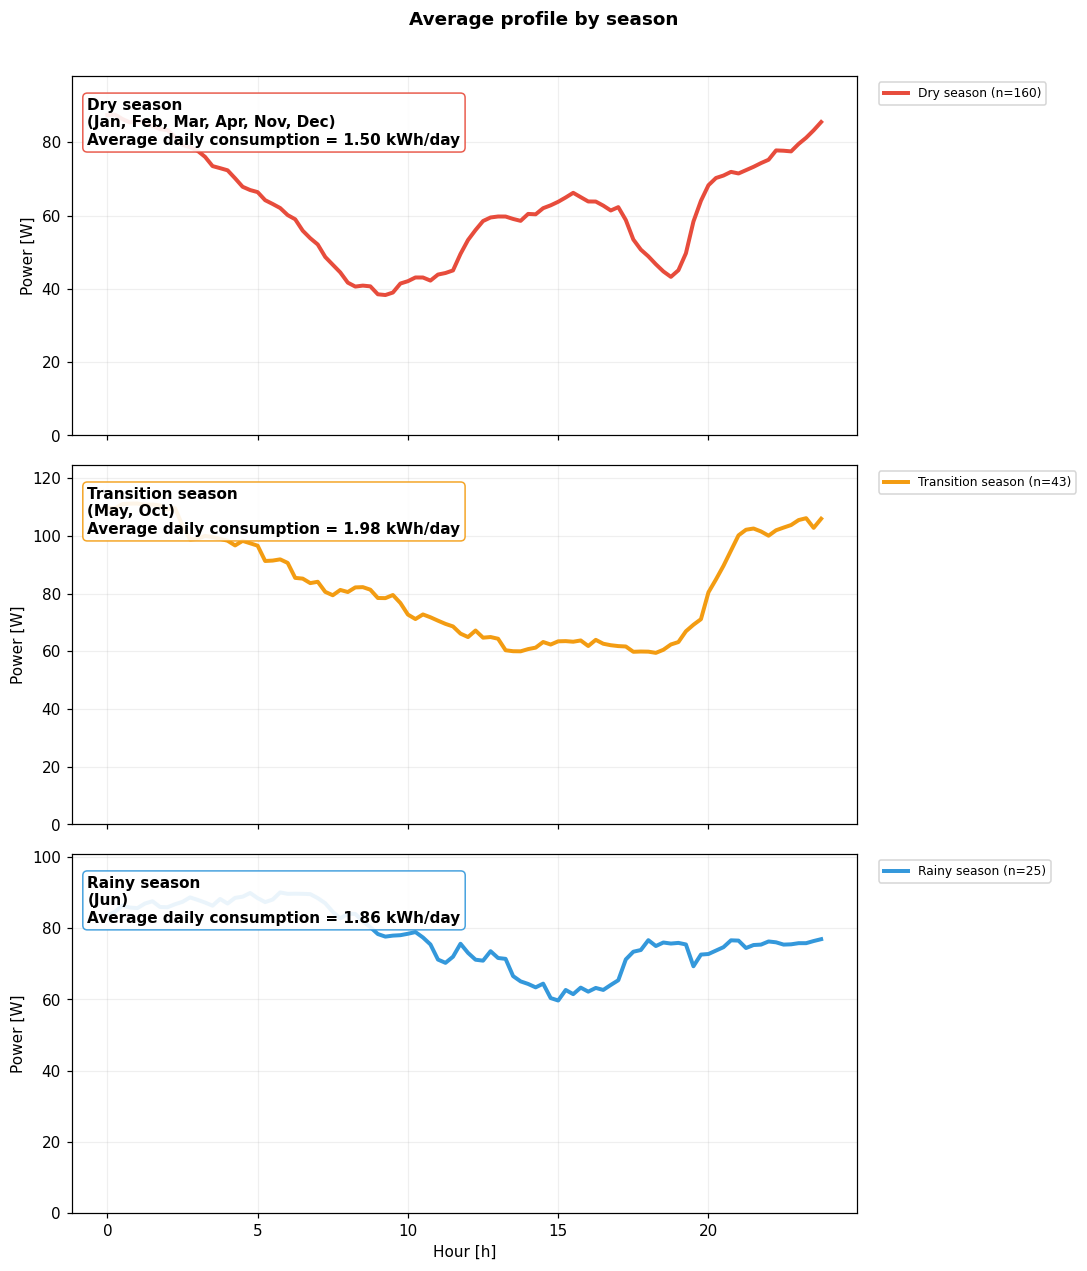

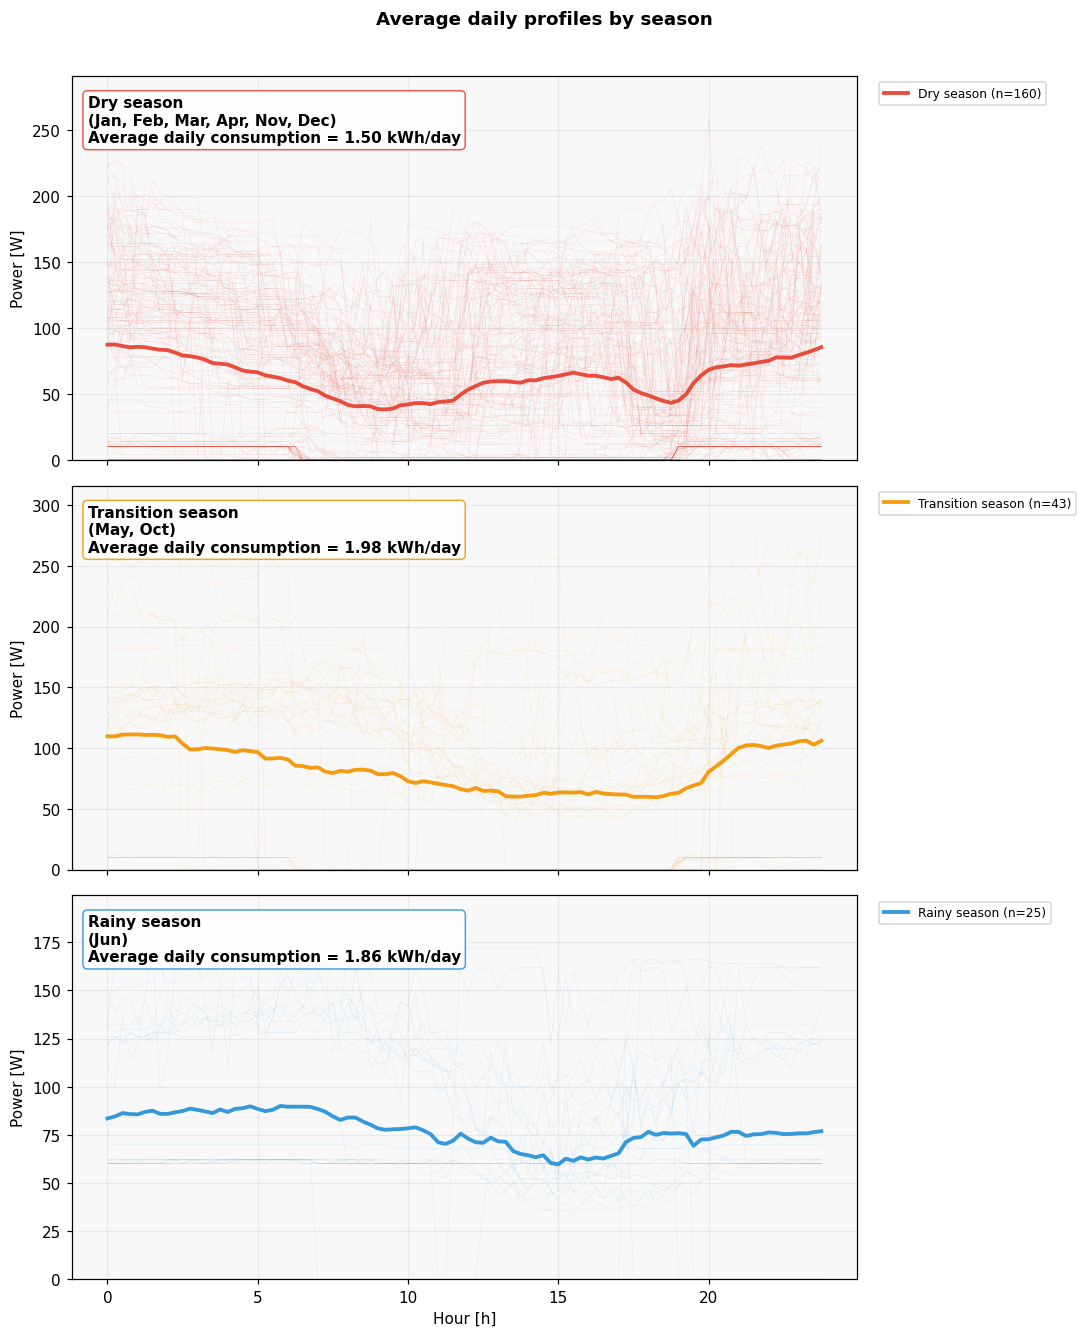

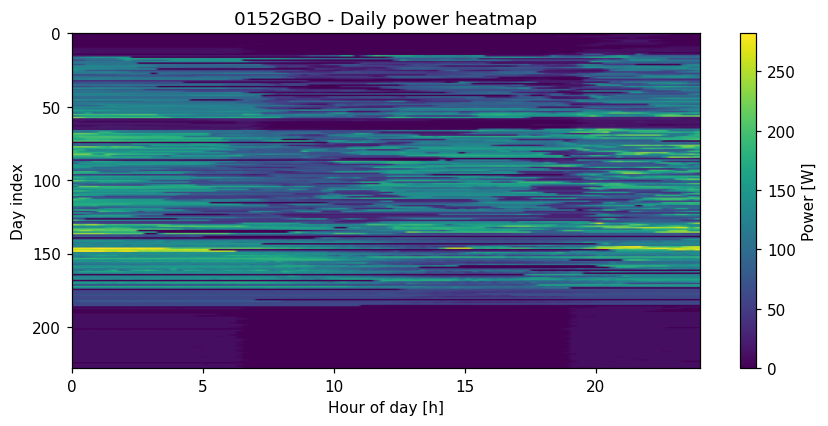

In [5]:
show("07_season_profiles.png", "07b_season_profiles_stacked.png",
     "0*_heatmap.png")

## Clustering

k-distance heuristic, cluster sizes, cluster profiles, feature
scatters and the season/cluster distribution.

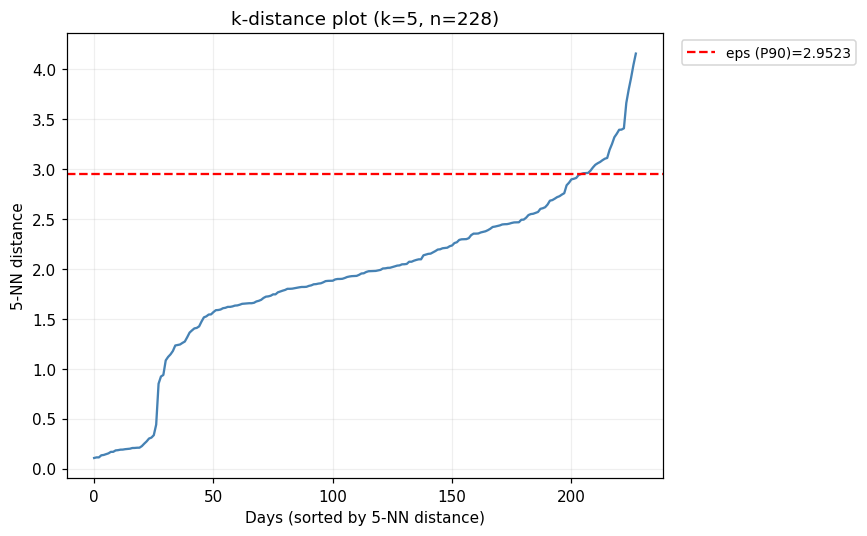

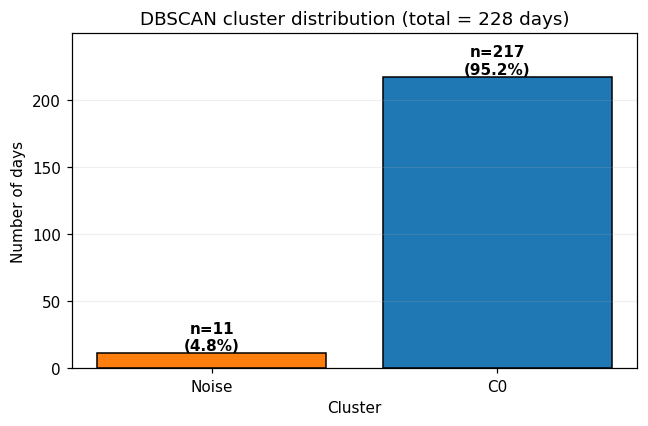

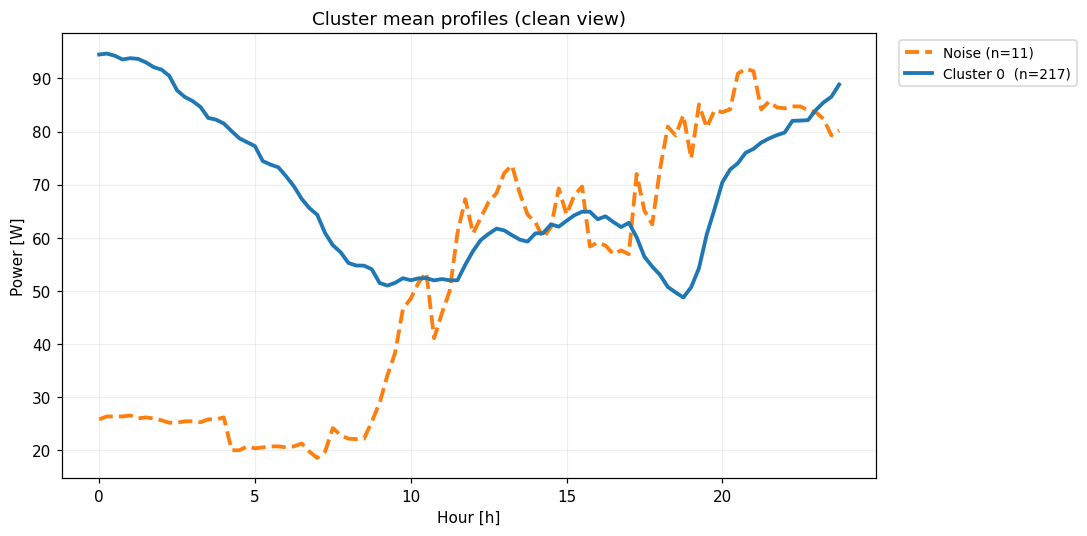

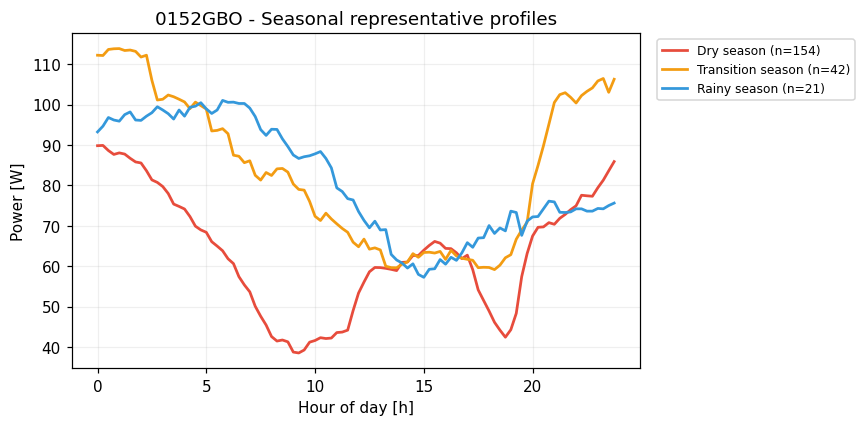

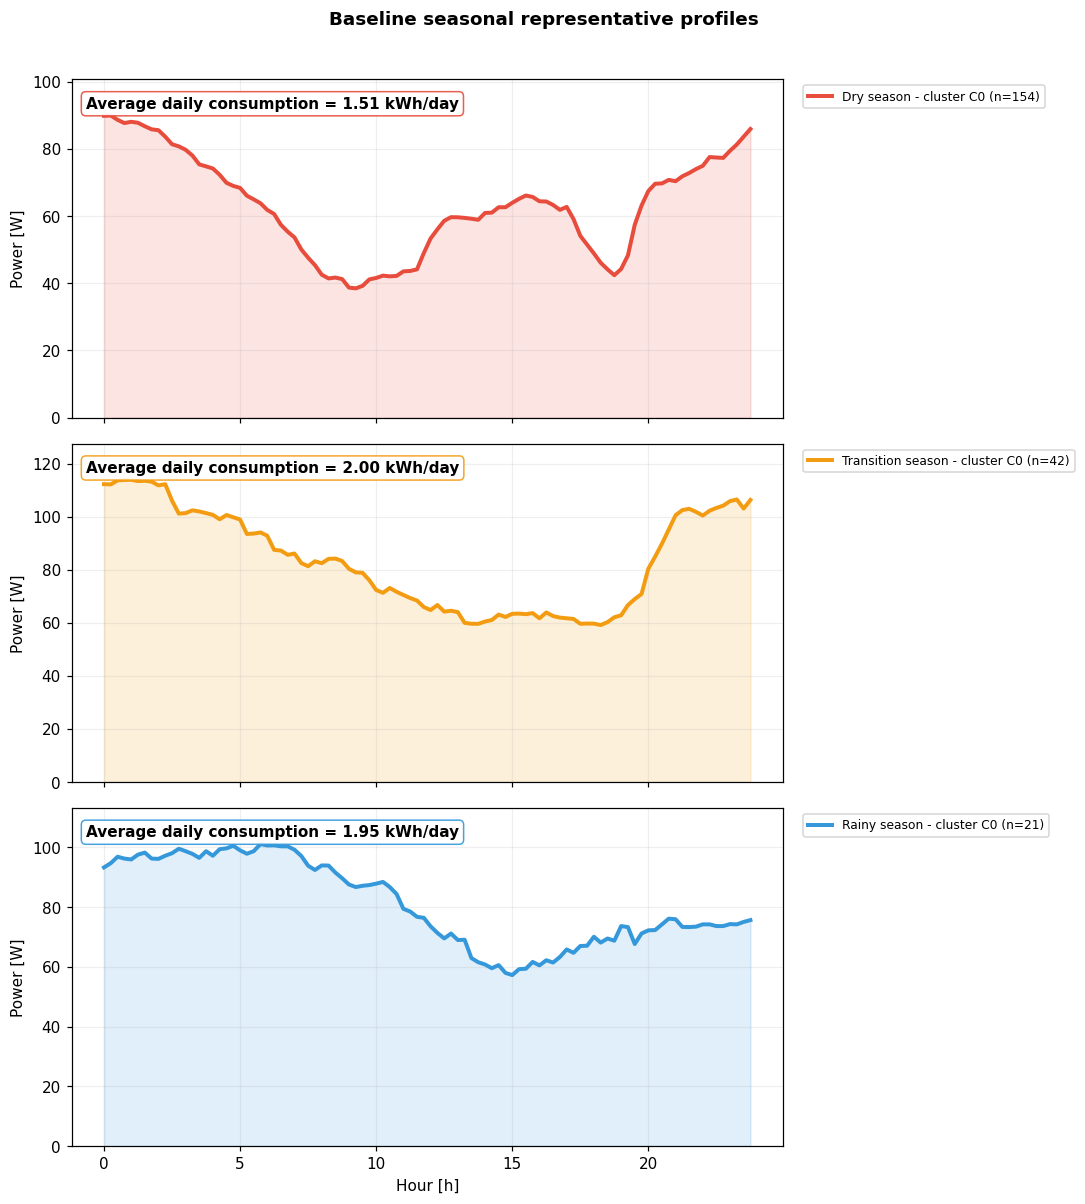

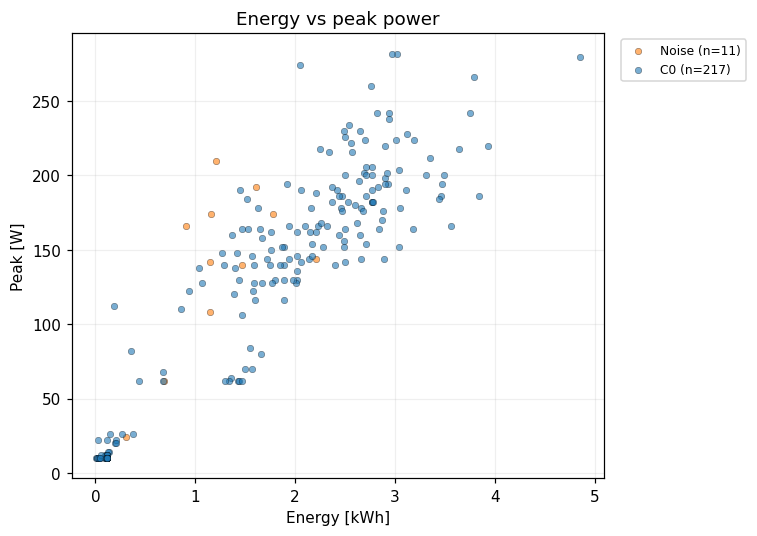

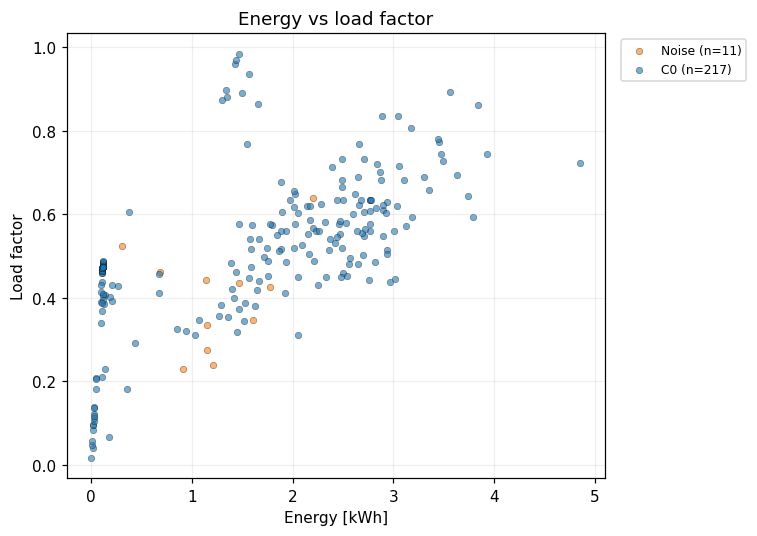

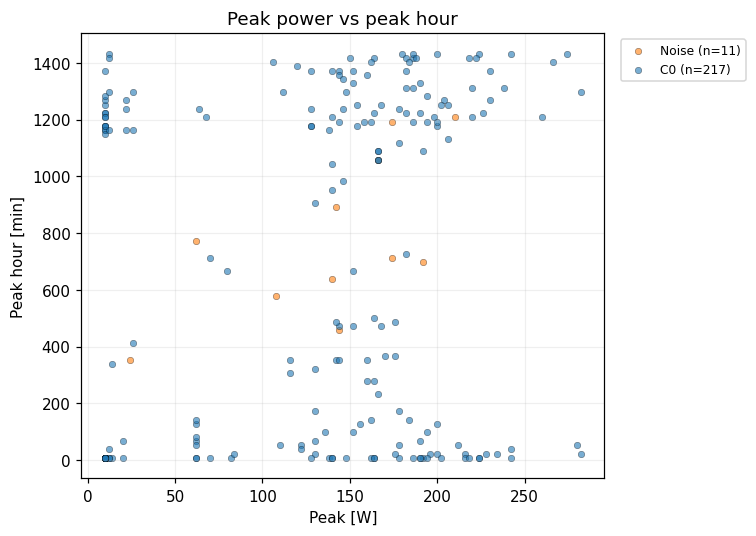

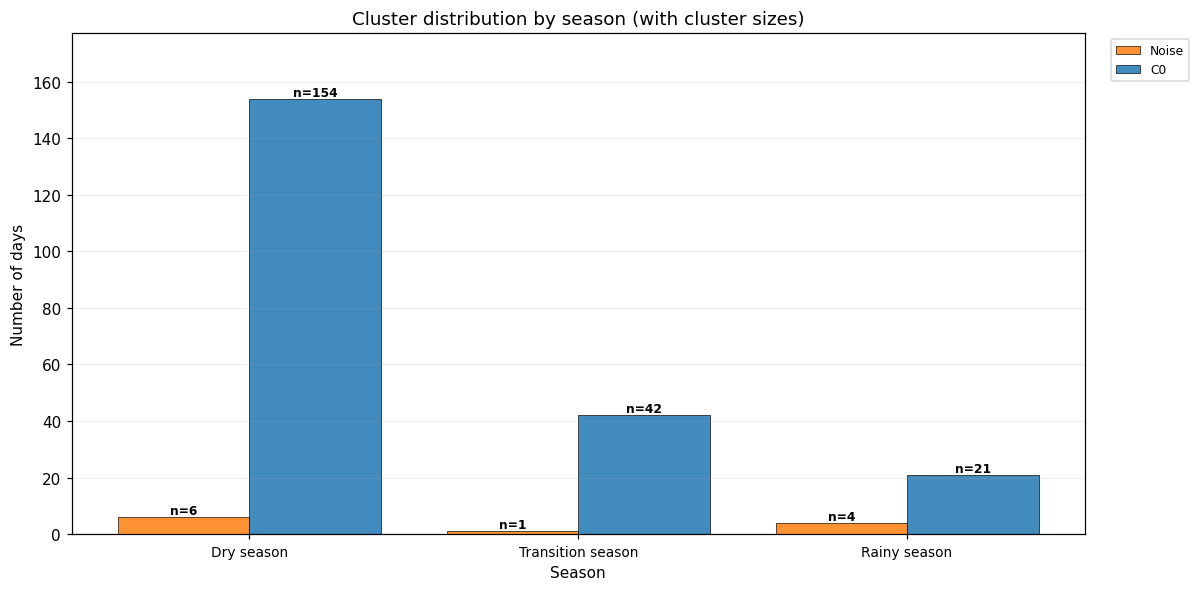

In [6]:
show("08_k_distance_plot.png", "0*_cluster_histogram.png",
     "*_cluster_profiles*.png", "*repr*.png",
     "12_scatter_E_Ppeak.png", "13_scatter_E_LF.png",
     "14_scatter_Ppeak_peakH.png", "15_season_cluster_bar.png")

## Dry season

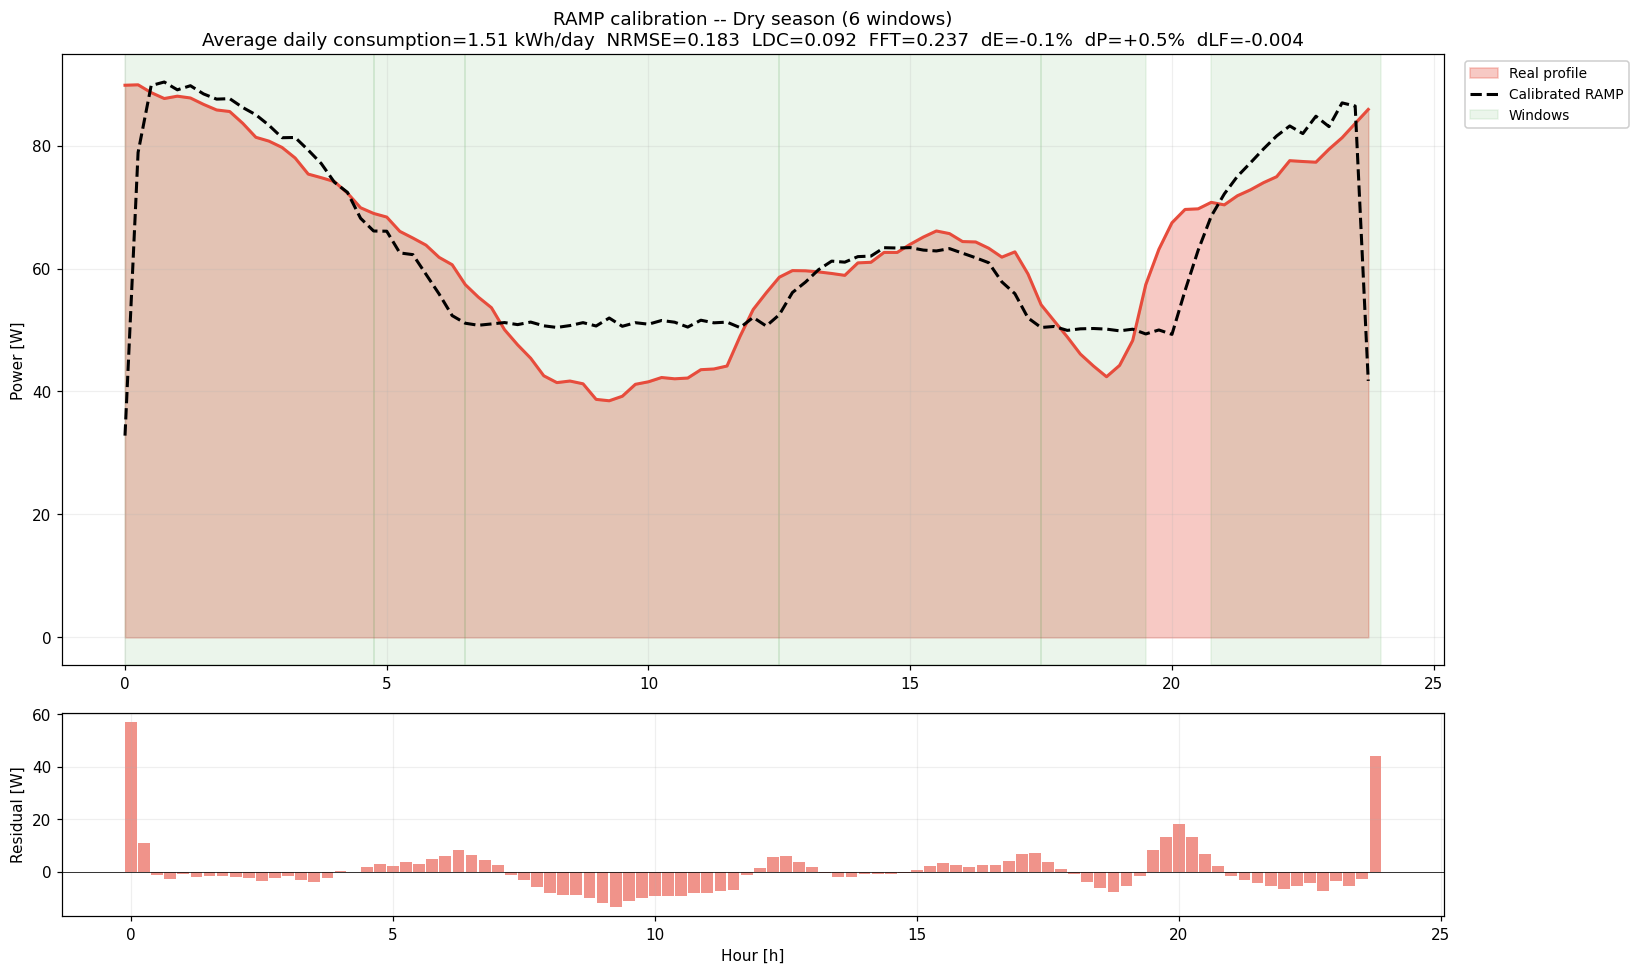

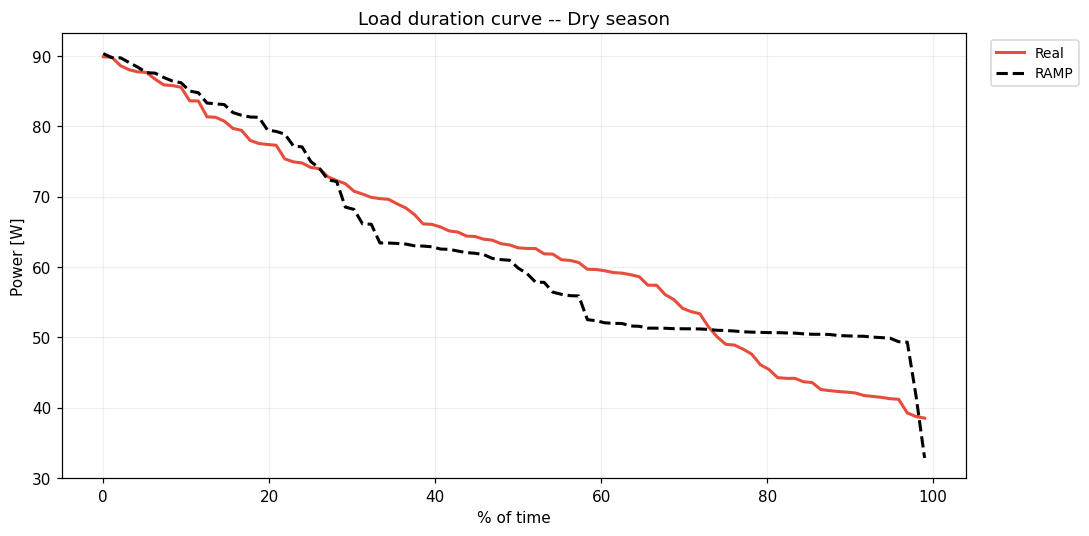

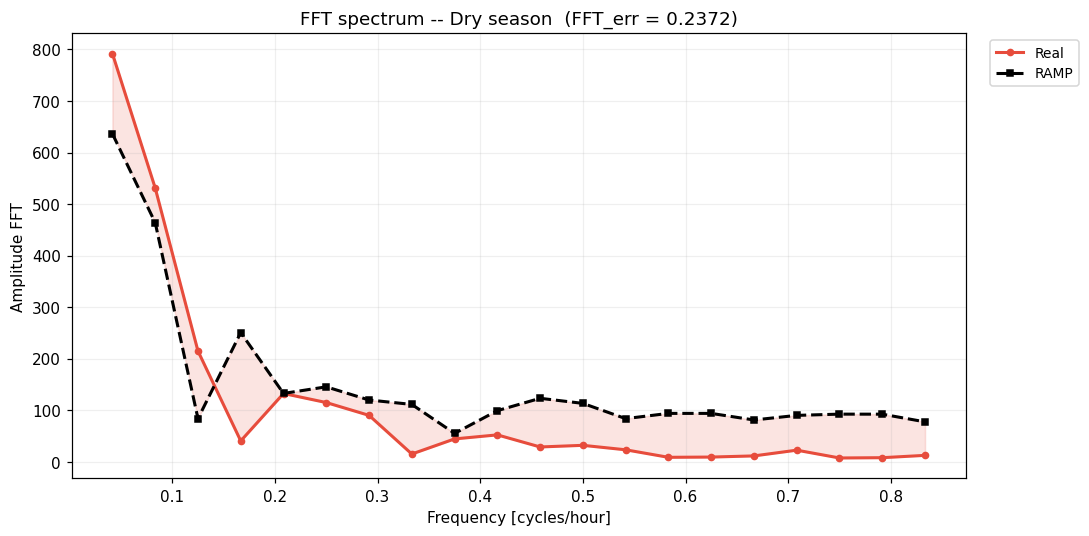

,season,n_pass,NRMSE,LDC_err,FFT_err,err_E_pct,err_P_pct,err_LF
0,Dry season,4,0.183,0.092,0.237,-0.06,0.507,-0.004


In [7]:
season = "Dry season"
val = pd.read_csv(RESULTS / "validation_metrics.csv")
row = val[val["season"] == season]
if row.empty:
    print("No calibration for this season (not enough measured days).")
else:
    show(f"40_calib_Dry_season.png", f"41_ldc_Dry_season.png", f"42_fft_Dry_season.png")
    wanted = ["season", "n_pass", "NRMSE", "LDC_err", "FFT_err",
              "err_E_pct", "err_P_pct", "err_LF"]
    cols = [c for c in wanted if c in row.columns]
    display(row[cols].round(3))

## Transition

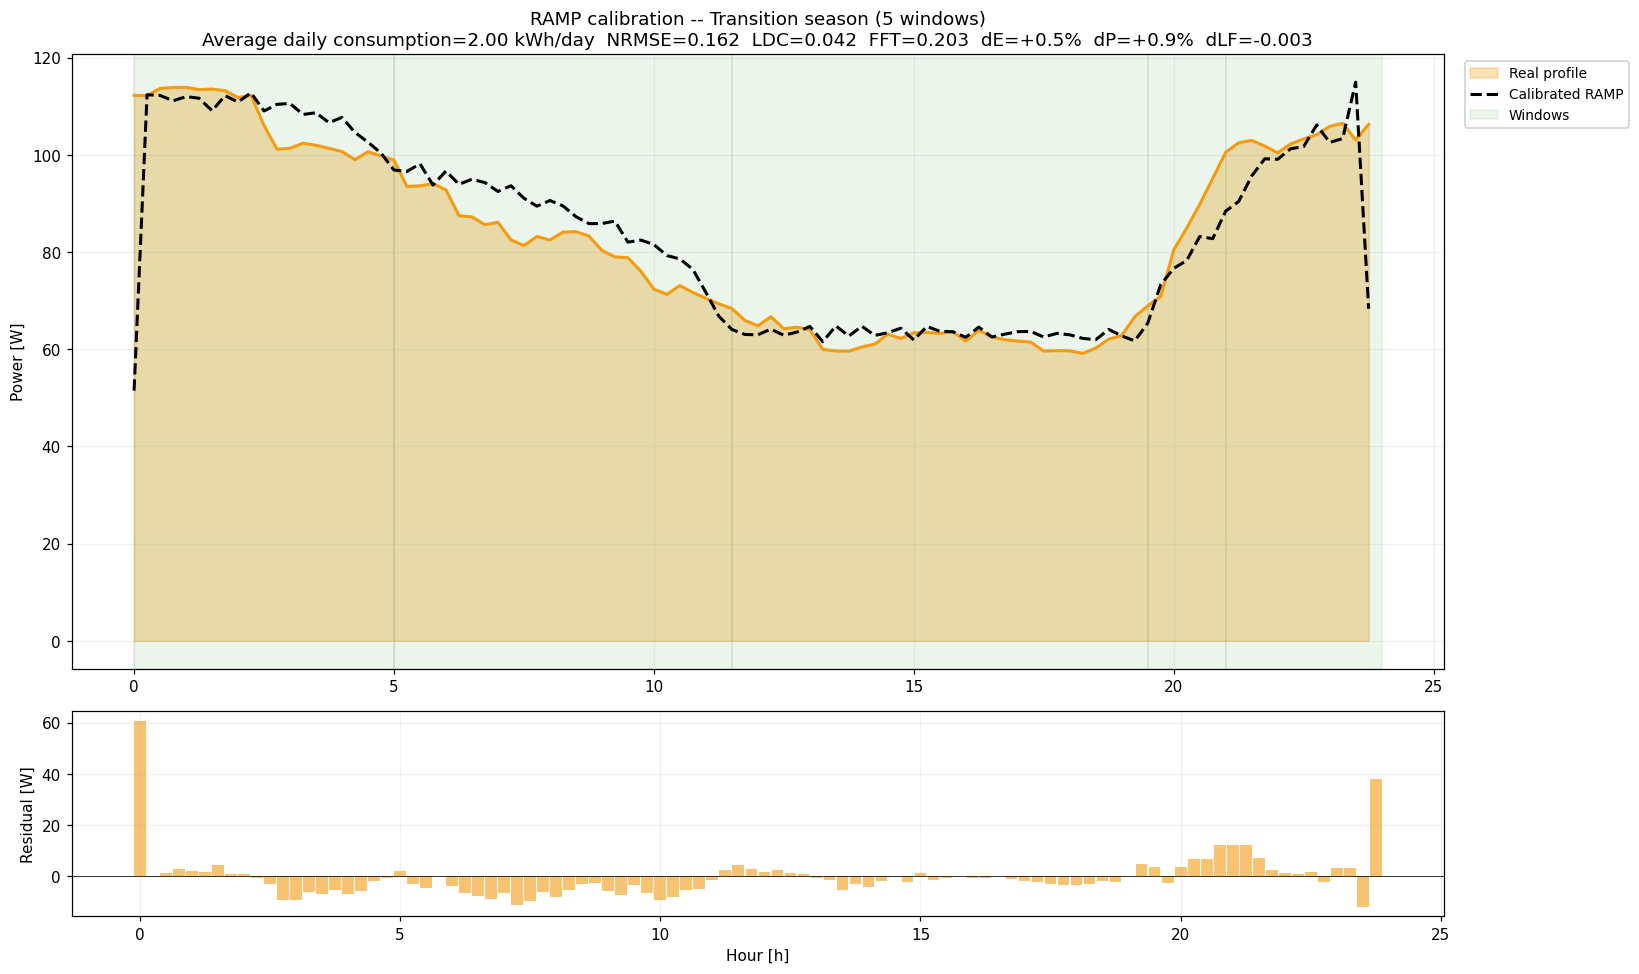

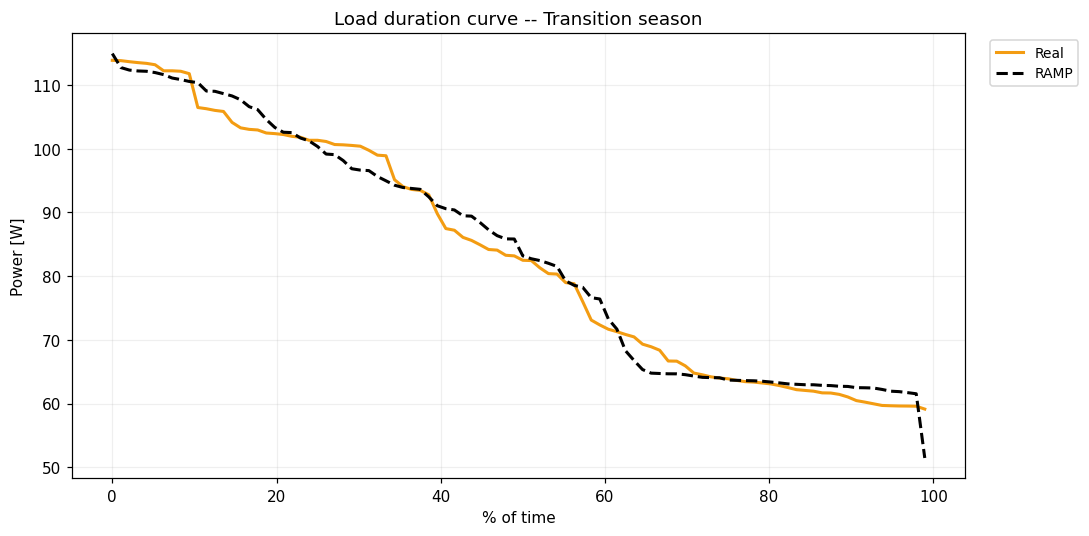

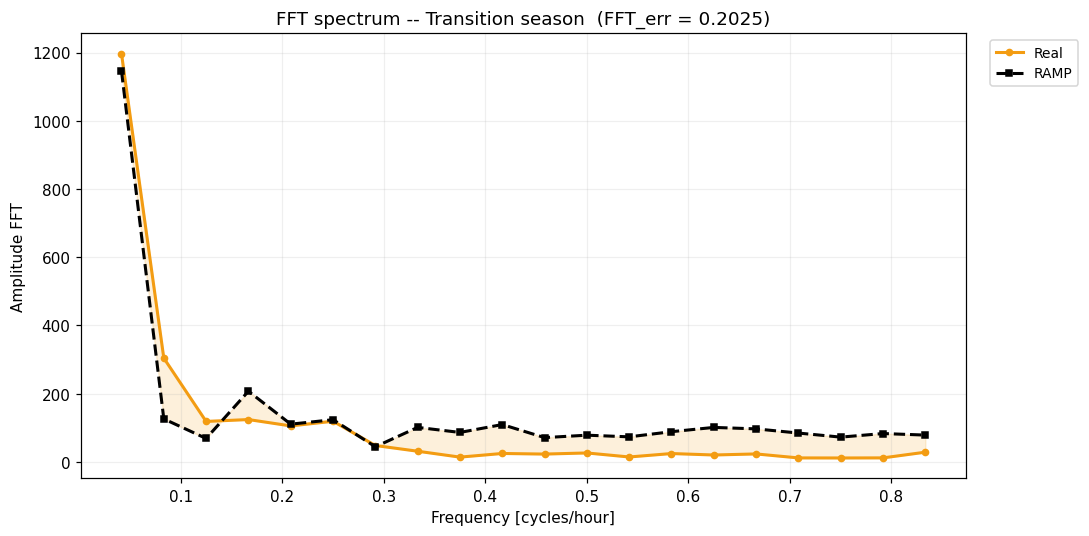

,season,n_pass,NRMSE,LDC_err,FFT_err,err_E_pct,err_P_pct,err_LF
1,Transition,4,0.162,0.042,0.203,0.468,0.93,-0.003


In [8]:
season = "Transition"
val = pd.read_csv(RESULTS / "validation_metrics.csv")
row = val[val["season"] == season]
if row.empty:
    print("No calibration for this season (not enough measured days).")
else:
    show(f"40_calib_Transition.png", f"41_ldc_Transition.png", f"42_fft_Transition.png")
    wanted = ["season", "n_pass", "NRMSE", "LDC_err", "FFT_err",
              "err_E_pct", "err_P_pct", "err_LF"]
    cols = [c for c in wanted if c in row.columns]
    display(row[cols].round(3))

## Rainy season

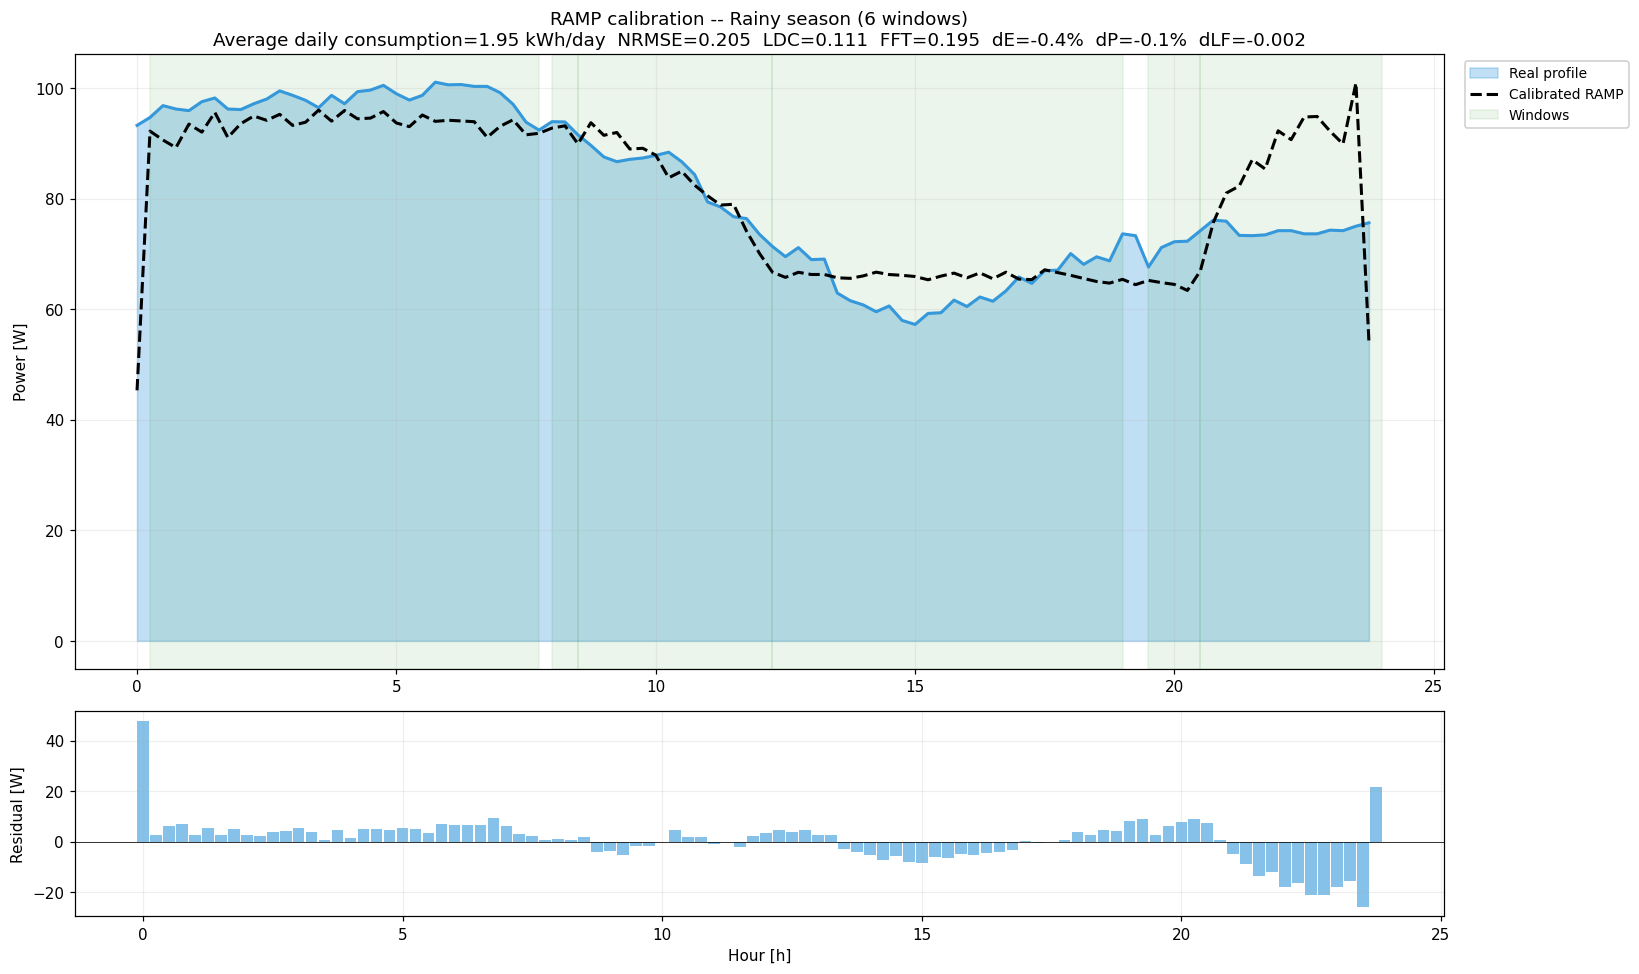

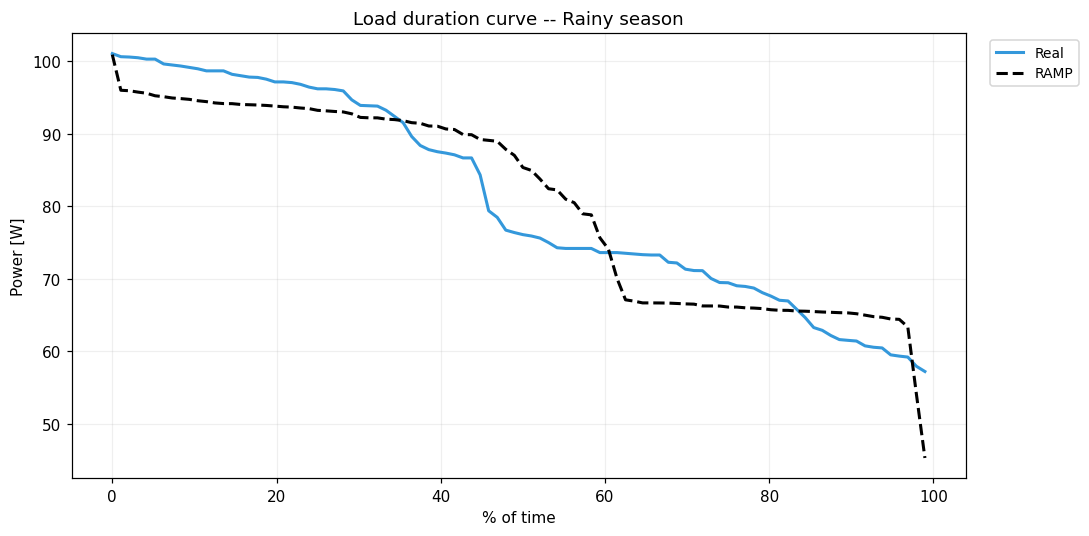

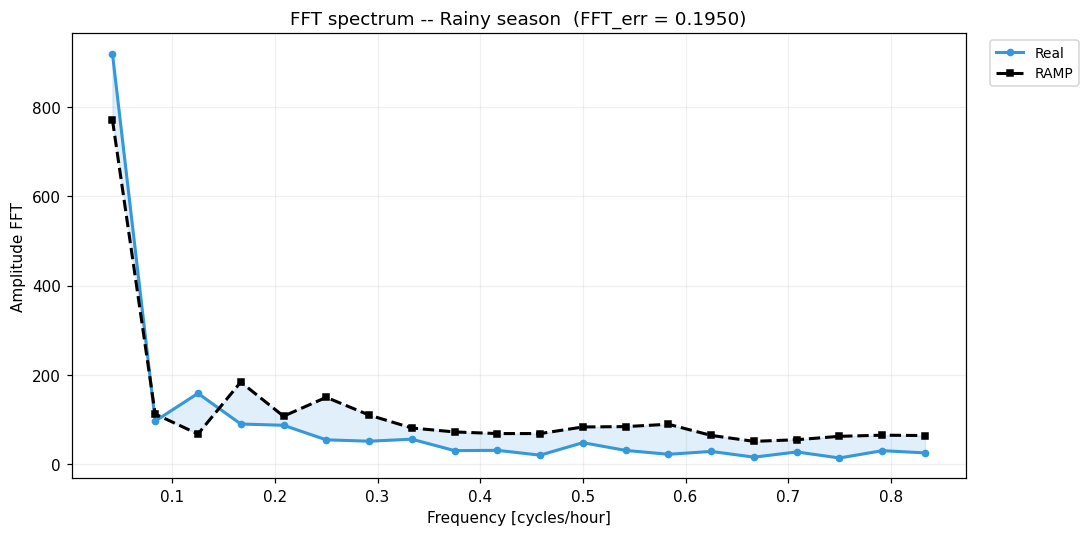

,season,n_pass,NRMSE,LDC_err,FFT_err,err_E_pct,err_P_pct,err_LF
2,Rainy season,4,0.205,0.111,0.195,-0.426,-0.145,-0.002


In [9]:
season = "Rainy season"
val = pd.read_csv(RESULTS / "validation_metrics.csv")
row = val[val["season"] == season]
if row.empty:
    print("No calibration for this season (not enough measured days).")
else:
    show(f"40_calib_Rainy_season.png", f"41_ldc_Rainy_season.png", f"42_fft_Rainy_season.png")
    wanted = ["season", "n_pass", "NRMSE", "LDC_err", "FFT_err",
              "err_E_pct", "err_P_pct", "err_LF"]
    cols = [c for c in wanted if c in row.columns]
    display(row[cols].round(3))

## Calibrated RAMP parameters

,season,p1,p2,cycles,func_cycle,random_var_w,time_frac_var,thermal_p_var
0,Dry season,127.500,19.682,"[{'p1': 127.5, 't1': 10, 'p2': 19.682438280438...",30.816,0.083,0.184,0.181
1,Transition,146.576,25.000,"[{'p1': 146.57649407947508, 't1': 8, 'p2': 25....",23.331,0.007,0.185,0.185
2,Rainy season,146.452,57.797,"[{'p1': 146.45153013175494, 't1': 4, 'p2': 57....",24.972,0.019,0.175,0.175


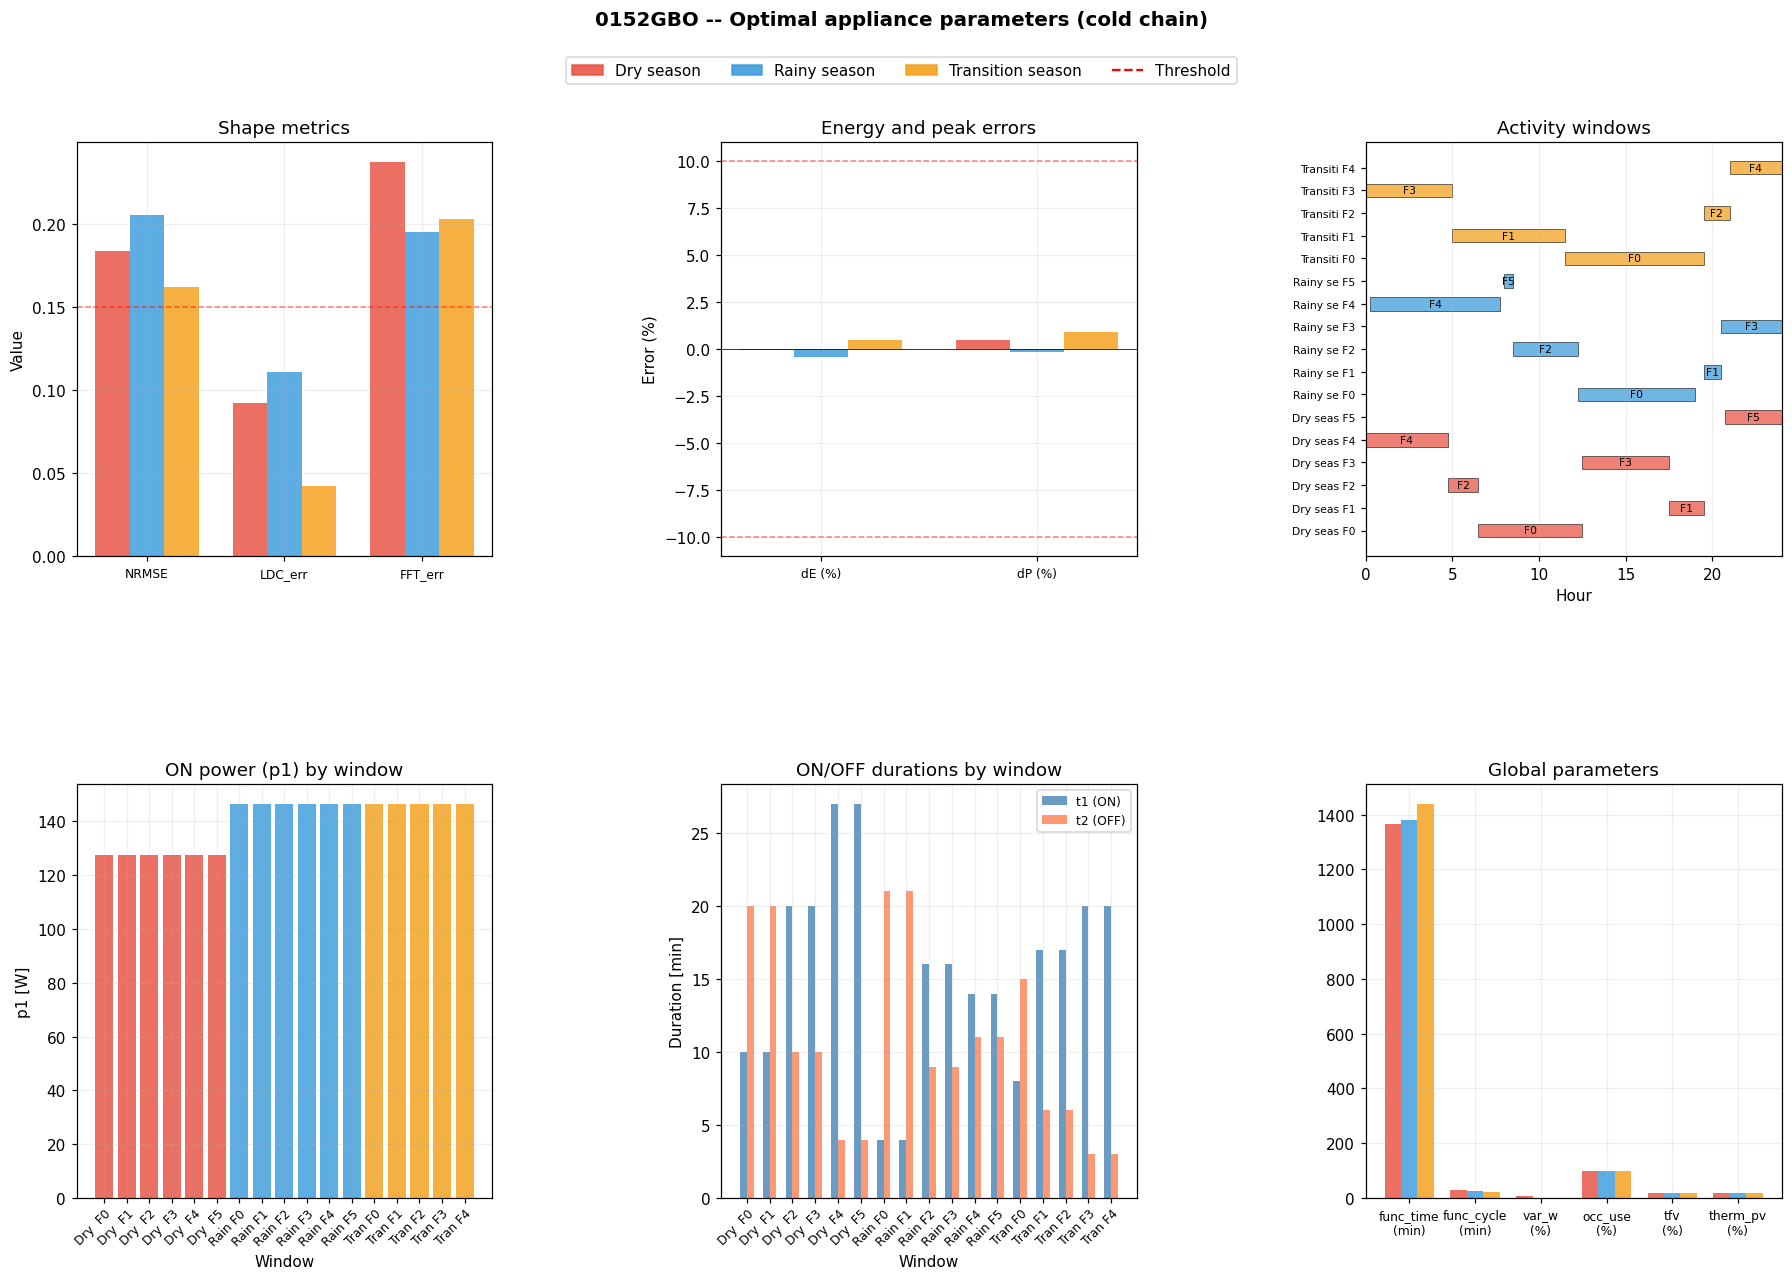

In [10]:
params = pd.read_csv(RESULTS / "ramp_calibrated_params.csv")
json_col = next((c for c in ("params_json", "decoded_json")
                 if c in params.columns), None)
if json_col:
    decoded = params[json_col].apply(json.loads).apply(pd.Series)
    table = pd.concat([params[["season"]], decoded], axis=1)
else:
    table = params
display(table.round(3))
show("50_param_summary.png")